# GliZNet Forward Pass — Cosine Similarity at Each Stage

Step-by-step visualization of how label and text representations relate through the aggregator.

The new architecture is simple:

| Stage | Labels | Text repr |
|-------|--------|-----------|
| 1. Raw | `[LAB]` token embeddings | CLS token (position 0) |
| 2. After Context Fusion | Same `[LAB]` embeddings (used as query) | `LabelContextFusion` output — labels attend to peer fused(CLS+label) views |

**Key insight**: The bilinear head scores `(context_text_repr, label_emb)` pairs. The text representation is produced by label interaction — each label sees how peers interpret the shared CLS.


In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from gliznet import GliZNetForSequenceClassification, GliZNETTokenizer

# Select GPU with most free memory
if torch.cuda.is_available():
    free_mem = [torch.cuda.mem_get_info(i)[0] for i in range(torch.cuda.device_count())]
    DEVICE = f"cuda:{free_mem.index(max(free_mem))}"
else:
    DEVICE = "cpu"

MODEL_PATH = "../results/deberta-v3-base_20260520_061319/checkpoint-32000"

model = GliZNetForSequenceClassification.from_pretrained(
    MODEL_PATH,
).to(DEVICE, dtype=torch.float16).eval()
tokenizer = GliZNETTokenizer.from_pretrained(MODEL_PATH)

print(f"Device: {DEVICE}")
print(f"Model loaded from: {MODEL_PATH}")
print(f"Hidden size: {model.aggregator.hidden_size}")
print(f"Scoring: {model.aggregator.scoring.__class__.__name__}")
print(f"Label context fusion: {model.aggregator.context is not None}")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Device: cuda:0
Model loaded from: ../results/deberta-v3-base_20260520_061319/checkpoint-32000
Hidden size: 768
Scoring: BilinearScoring
Label context fusion: True


In [2]:
# Define a sample text with labels (mix of true and false)
text = "New research shows that moderate coffee consumption may reduce the risk of Alzheimer's disease by up to 30%."
labels = ["medical_research", "nutrition_advice", "drug_development", "disease_prevention", "public_health_policy"]
expected = [True, False, False, True, False]

text = "After years of training and countless sacrifices, the athlete finally stood on the Olympic podium, tears streaming down her face as the national anthem played."
labels = ["athletic_achievement", "personal_sacrifice", "patriotism", "emotional_moment", "celebrity_gossip", "sports_injury", "political_protest", "entertainment_review", "historical_analysis", "travel_experience"]
expected = [True, True, True, True, False, False, False, False, False, False]

# Tokenize
batch = tokenizer([(text, labels)], return_tensors="pt")
batch = {k: v.to(DEVICE) for k, v in batch.items()}

print(f"Input shape: {batch['input_ids'].shape}")
print(f"Labels: {labels}")
print(f"\nExpected true:  {[l for l, e in zip(labels, expected) if e]}")
print(f"Expected false: {[l for l, e in zip(labels, expected) if not e]}")

Input shape: torch.Size([1, 70])
Labels: ['athletic_achievement', 'personal_sacrifice', 'patriotism', 'emotional_moment', 'celebrity_gossip', 'sports_injury', 'political_protest', 'entertainment_review', 'historical_analysis', 'travel_experience']

Expected true:  ['athletic_achievement', 'personal_sacrifice', 'patriotism', 'emotional_moment']
Expected false: ['celebrity_gossip', 'sports_injury', 'political_protest', 'entertainment_review', 'historical_analysis', 'travel_experience']


## Capture All Stages

Run the aggregator step by step:
1. Extract CLS + [LAB] token embeddings from encoder
2. LabelContextFusion: fuse(CLS, label_j) → labels attend to peer fused views → text_repr
3. BilinearScoring: score(text_repr, label_emb)


In [3]:
@torch.no_grad()
def get_all_stages(model, batch, labels):
    """Run the forward pass step by step, matching aggregator.py exactly."""
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    
    # Stage 1: Raw encoder output
    encoder_output = model.backbone(input_ids=input_ids, attention_mask=attention_mask)
    hidden_states = encoder_output.last_hidden_state  # (B, L, D)
    
    agg = model.aggregator
    B, L, D = hidden_states.shape
    
    # CLS token — global text representation
    cls_emb = hidden_states[0, 0]  # (D,)
    
    # Raw [LAB] token embeddings (before dropout)
    lab_token_mask = input_ids == agg.lab_token_id
    lab_positions = lab_token_mask[0].nonzero(as_tuple=True)[0]
    raw_label_embs = hidden_states[0, lab_positions]  # (K, D)
    
    # Stage 2: Aggregate labels (same as aggregator.aggregate_labels)
    aggregated_labels, all_batch_ids, all_label_ids, max_k = agg.aggregate_labels(
        input_ids, hidden_states
    )
    
    # Stage 3: Context fusion (if enabled)
    if agg.context is not None:
        # Build dense label tensor
        dense_labels = aggregated_labels.new_zeros(B, max_k, D)
        dense_labels[all_batch_ids, all_label_ids - 1] = aggregated_labels
        
        label_mask = torch.zeros(B, max_k, dtype=torch.bool, device=hidden_states.device)
        label_mask[all_batch_ids, all_label_ids - 1] = True
        
        # CLS as shared text context
        text_cls = hidden_states[:, 0]  # (B, D)
        
        # LabelContextFusion: labels attend to peer fused views
        text_repr_dense = agg.context(dense_labels, text_cls, label_mask)
        text_repr = text_repr_dense[all_batch_ids, all_label_ids - 1]  # (N, D)
    else:
        text_repr = hidden_states[:, 0][all_batch_ids]  # (N, D)
    
    # Stage 4: Bilinear scores (with LayerNorm)
    logits = agg.scoring(text_repr, aggregated_labels)
    scores = torch.sigmoid(logits).squeeze(-1)
    
    # Also capture post-LayerNorm representations (what bilinear actually sees)
    norm = agg.scoring.norm
    text_normed = norm(text_repr)
    label_normed = norm(aggregated_labels)
    
    return {
        # Raw stage
        "raw_label_embs": raw_label_embs,        # (K, D)
        "cls_emb": cls_emb,                      # (D,)
        # After aggregation (dropout applied in eval=noop)
        "agg_label_embs": aggregated_labels,     # (N, D)
        # Context fusion output = text representation
        "text_repr": text_repr,                  # (N, D)
        # Post-LayerNorm (actual bilinear inputs)
        "text_normed": text_normed,              # (N, D)
        "label_normed": label_normed,            # (N, D)
        # Final scores
        "logits": logits.squeeze(-1),
        "scores": scores,
        "labels": labels,
    }

stages = get_all_stages(model, batch, labels)
print("All stages captured.")
print(f"  Raw labels:     {stages['raw_label_embs'].shape}")
print(f"  Agg labels:     {stages['agg_label_embs'].shape}")
print(f"  Text repr:      {stages['text_repr'].shape}")
print(f"  Text normed:    {stages['text_normed'].shape}")
print(f"  Label normed:   {stages['label_normed'].shape}")

All stages captured.
  Raw labels:     torch.Size([10, 768])
  Agg labels:     torch.Size([10, 768])
  Text repr:      torch.Size([10, 768])
  Text normed:    torch.Size([10, 768])
  Label normed:   torch.Size([10, 768])


In [4]:
def cos_sim(a, b):
    """Cosine similarity between vectors/matrices."""
    a = F.normalize(a.float(), p=2, dim=-1)
    b = F.normalize(b.float(), p=2, dim=-1)
    return (a @ b.T).detach().cpu().numpy()


def l2_dist(a, b):
    """Pairwise L2 distance between vectors."""
    a, b = a.float(), b.float()
    return torch.cdist(a.unsqueeze(0), b.unsqueeze(0)).squeeze(0).detach().cpu().numpy()


def bilinear_matrix(scoring, text, labels):
    """Compute full bilinear score matrix: score(text_i, label_j) for all i,j."""
    K = labels.shape[0]
    norm = scoring.norm
    text_n = norm(text)   # (K, D)
    label_n = norm(labels)  # (K, D)
    # bilinear expects matching shapes; compute all pairs
    scores = torch.zeros(K, K)
    for i in range(K):
        text_i = text_n[i:i+1].expand(K, -1)  # (K, D)
        scores[i] = scoring.bilinear(text_i, label_n).squeeze(-1).detach()
    return scores.cpu().numpy()


print("Helpers ready.")

Helpers ready.


## Label ↔ Text Representations

- **Raw**: `cos(label_i, CLS)` — all labels see the same global text summary
- **After Context**: `cos(label_i, text_repr_i)` — label-specific text from context fusion
- **L2 to CLS**: Euclidean distance shows magnitude differences invisible to cosine

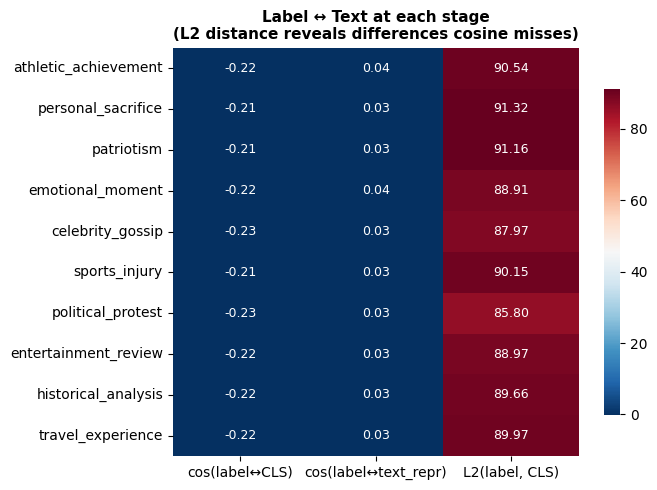


Label                       cos↔CLS   cos↔repr   L2↔CLS   Exp
────────────────────────────────────────────────────────────
athletic_achievement        -0.2176     0.0355     90.5     T
personal_sacrifice          -0.2058     0.0313     91.3     T
patriotism                  -0.2146     0.0346     91.2     T
emotional_moment            -0.2224     0.0381     88.9     T
celebrity_gossip            -0.2258     0.0276     88.0     F
sports_injury               -0.2122     0.0304     90.1     F
political_protest           -0.2296     0.0271     85.8     F
entertainment_review        -0.2188     0.0276     89.0     F
historical_analysis         -0.2230     0.0293     89.7     F
travel_experience           -0.2158     0.0290     90.0     F


In [5]:
cls = stages["cls_emb"].unsqueeze(0)  # (1, D)

# Raw: each label vs CLS
sim_raw = cos_sim(stages["raw_label_embs"], cls).flatten()  # (K,)

# After context fusion: each label vs its text_repr
sim_context = np.array([
    cos_sim(stages["agg_label_embs"][i:i+1], stages["text_repr"][i:i+1]).item()
    for i in range(len(labels))
])

# L2 distances: labels to CLS, and between text_repr vectors
l2_to_cls = np.array([
    torch.norm(stages["raw_label_embs"][i].float() - cls.float().squeeze()).item()
    for i in range(len(labels))
])

# Heatmap: (K, 3) matrix
sim_matrix = np.column_stack([sim_raw, sim_context, l2_to_cls])
stage_cols = ["cos(label↔CLS)", "cos(label↔text_repr)", "L2(label, CLS)"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    sim_matrix, ax=ax, cmap="RdBu_r",
    xticklabels=stage_cols, yticklabels=labels,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Label ↔ Text at each stage\n(L2 distance reveals differences cosine misses)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# Table
print(f"\n{'Label':<25} {'cos↔CLS':>9} {'cos↔repr':>10} {'L2↔CLS':>8} {'Exp':>5}")
print("─" * 60)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    print(f"{lbl:<25} {sim_raw[i]:>9.4f} {sim_context[i]:>10.4f} {l2_to_cls[i]:>8.1f} {'T' if exp else 'F':>5}")

## Labels vs Text Tokens

How each [LAB] embedding relates to individual text tokens (raw encoder cosine).
Note: this is NOT part of the aggregator — purely a diagnostic visualization.


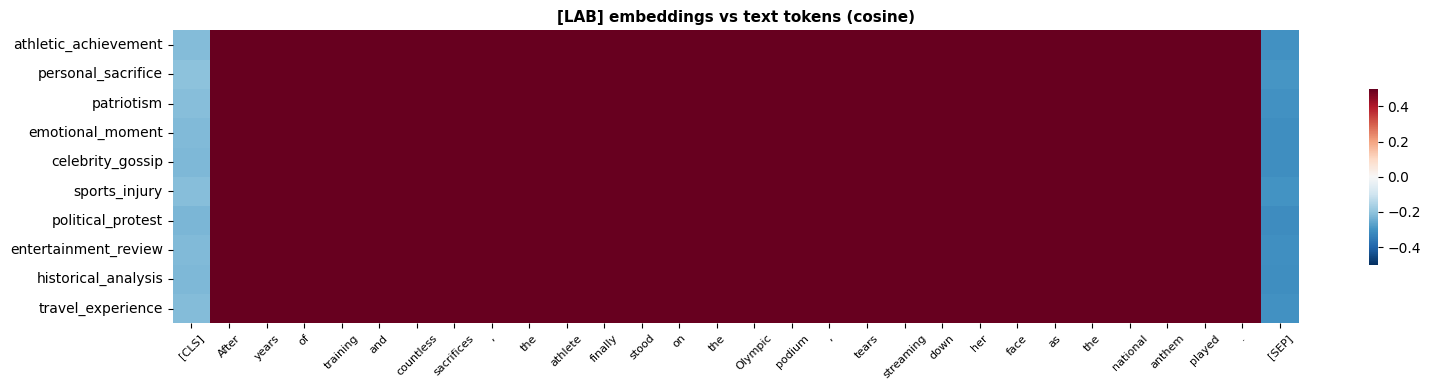

In [6]:
# Rerun encoder to get hidden states for token-level viz
with torch.no_grad():
    hidden_states = model.backbone(
        input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
    ).last_hidden_state

# Find text token positions (exclude [LAB] and padding)
lab_token_mask = batch["input_ids"] == model.aggregator.lab_token_id
lmask = batch["lmask"]
text_mask = (lmask == 0) & (batch["attention_mask"] == 1) & (~lab_token_mask)
text_positions = text_mask[0].nonzero(as_tuple=True)[0]
text_token_embs = hidden_states[0, text_positions]

# Get text token strings for x-axis labels
token_ids = batch["input_ids"][0, text_positions].cpu().tolist()
token_strs = tokenizer.tokenizer.convert_ids_to_tokens(token_ids)
token_strs = [t.replace("▁", "")[:12] for t in token_strs]

# Similarity: [LAB] embeddings vs text tokens
sim_label_text = cos_sim(stages["raw_label_embs"], text_token_embs)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    sim_label_text, ax=ax, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
    xticklabels=token_strs, yticklabels=labels,
    cbar_kws={"shrink": 0.6},
)
ax.set_title("[LAB] embeddings vs text tokens (cosine)", fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

## Pairwise Analysis

1. **Label ↔ Label L2 distance** — How labels differ in absolute embedding space
2. **Label ↔ Label cosine (post-LayerNorm)** — Directional variation at scoring input
3. **Bilinear score matrix** — `bilinear(norm(text_repr_i), norm(label_j))` — the actual scoring surface

Note: Raw cosine between [LAB] embeddings is ~0.99-1.00 (they share a dominant component),
but the model discriminates via LayerNorm + bilinear which operates on element-wise differences.

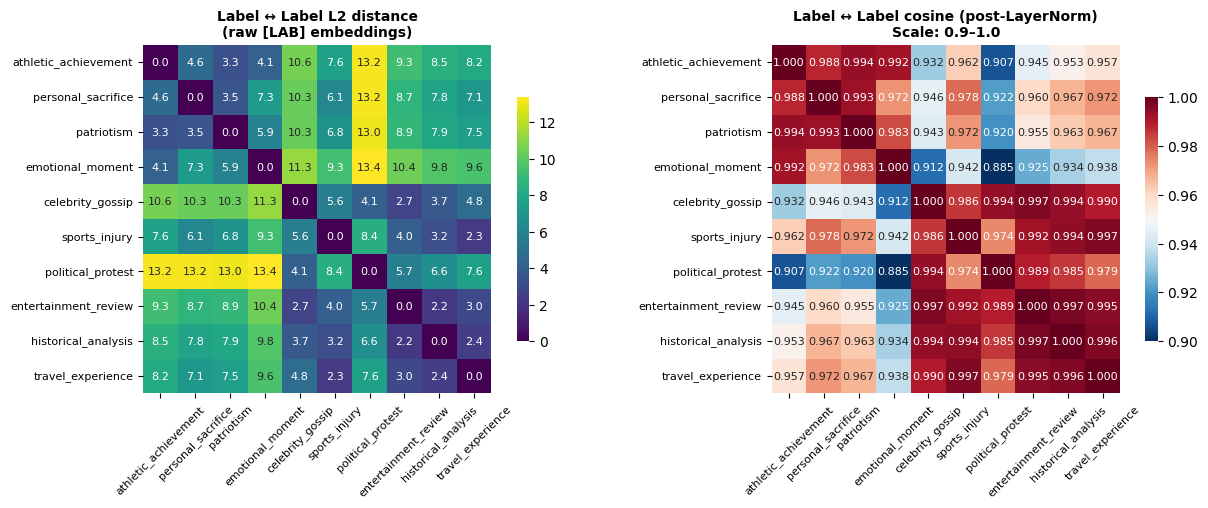

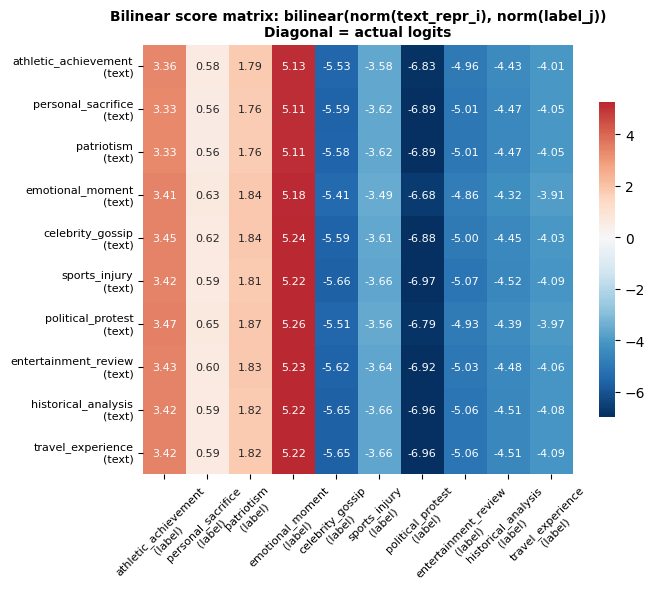


Diagonal — matched pairs (= model logits):
Label                     bilinear(i,i)  model logit   Expected
─────────────────────────────────────────────────────────────────
athletic_achievement              3.359        3.359       TRUE
personal_sacrifice                0.557        0.557       TRUE
patriotism                        1.761        1.761       TRUE
emotional_moment                  5.180        5.180       TRUE
celebrity_gossip                 -5.586       -5.586      FALSE
sports_injury                    -3.664       -3.664      FALSE
political_protest                -6.789       -6.789      FALSE
entertainment_review             -5.031       -5.031      FALSE
historical_analysis              -4.508       -4.508      FALSE
travel_experience                -4.086       -4.086      FALSE


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 1. LABEL ↔ LABEL — L2 distance (shows actual differences)
# ──────────────────────────────────────────────────────────────────────────────
dist_ll = l2_dist(stages["agg_label_embs"], stages["agg_label_embs"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    dist_ll, ax=axes[0], cmap="viridis",
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt=".1f", annot_kws={"size": 8},
    square=True, cbar_kws={"shrink": 0.7},
)
axes[0].set_title("Label ↔ Label L2 distance\n(raw [LAB] embeddings)", fontsize=10, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

# Also show post-LayerNorm cosine (more variation than raw cosine)
sim_ln = cos_sim(stages["label_normed"], stages["label_normed"])
sns.heatmap(
    sim_ln, ax=axes[1], vmin=0.9, vmax=1.0, cmap="RdBu_r",
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt=".3f", annot_kws={"size": 8},
    square=True, cbar_kws={"shrink": 0.7},
)
axes[1].set_title("Label ↔ Label cosine (post-LayerNorm)\nScale: 0.9–1.0", fontsize=10, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 2. BILINEAR SCORE MATRIX — the actual scoring surface
#    Diagonal = the matched (text_repr_i, label_i) scores = final logits
#    Off-diagonal = what-if: text_repr_i scored against label_j
# ──────────────────────────────────────────────────────────────────────────────
score_matrix = bilinear_matrix(model.aggregator.scoring, stages["text_repr"], stages["agg_label_embs"])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    score_matrix, ax=ax, cmap="RdBu_r", center=0,
    xticklabels=[f"{l}\n(label)" for l in labels],
    yticklabels=[f"{l}\n(text)" for l in labels],
    annot=True, fmt=".2f", annot_kws={"size": 8},
    square=True, cbar_kws={"shrink": 0.7},
)
ax.set_title("Bilinear score matrix: bilinear(norm(text_repr_i), norm(label_j))\n"
             "Diagonal = actual logits",
             fontsize=10, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

# Print diagonal comparison
print("\nDiagonal — matched pairs (= model logits):")
print(f"{'Label':<25} {'bilinear(i,i)':>13} {'model logit':>12} {'Expected':>10}")
print("─" * 65)
logits_np = stages["logits"].cpu().numpy()
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    print(f"{lbl:<25} {score_matrix[i, i]:>13.3f} {logits_np[i]:>12.3f} {'TRUE' if exp else 'FALSE':>10}")

## Final Bilinear Scores

The scoring head: `bilinear(LayerNorm(text_repr), LayerNorm(label_emb))` → logit → sigmoid.


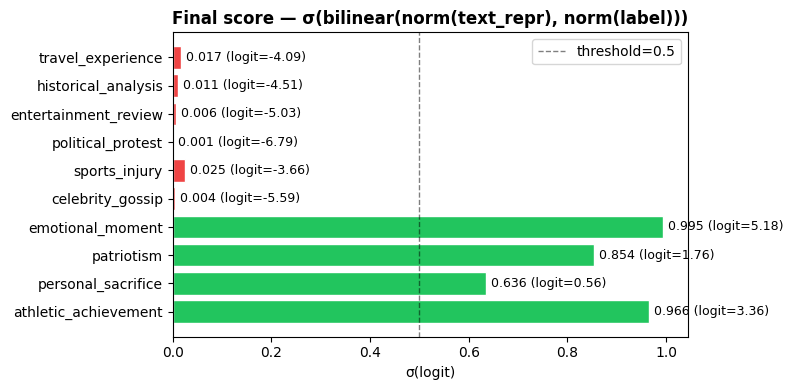


Label                    Raw↔CLS  ↔text_repr   Logit      σ  Exp
─────────────────────────────────────────────────────────────────
athletic_achievement      -0.218       0.036    3.36  0.966   T ✓
personal_sacrifice        -0.206       0.031    0.56  0.636   T ✓
patriotism                -0.215       0.035    1.76  0.854   T ✓
emotional_moment          -0.222       0.038    5.18  0.995   T ✓
celebrity_gossip          -0.226       0.028   -5.59  0.004   F ✓
sports_injury             -0.212       0.030   -3.66  0.025   F ✓
political_protest         -0.230       0.027   -6.79  0.001   F ✓
entertainment_review      -0.219       0.028   -5.03  0.006   F ✓
historical_analysis       -0.223       0.029   -4.51  0.011   F ✓
travel_experience         -0.216       0.029   -4.09  0.017   F ✓


In [8]:
# Final bilinear scores
final_scores = stages["scores"].cpu().numpy()
final_logits = stages["logits"].cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#22c55e" if e else "#ef4444" for e in expected]
ax.barh(labels, final_scores, color=colors, edgecolor="white")
ax.set_xlabel("σ(logit)")
ax.set_title("Final score — σ(bilinear(norm(text_repr), norm(label)))", fontweight="bold")
ax.axvline(0.5, color="black", ls="--", lw=1, alpha=0.5, label="threshold=0.5")
ax.legend()
for i, (v, l) in enumerate(zip(final_scores, final_logits)):
    ax.text(v + 0.01, i, f"{v:.3f} (logit={l:.2f})", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Full table
print(f"\n{'Label':<22} {'Raw↔CLS':>9} {'↔text_repr':>11} {'Logit':>7} {'σ':>6} {'Exp':>4}")
print("─" * 65)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    mark = "✓" if (final_scores[i] > 0.5) == exp else "✗"
    print(f"{lbl:<22} {sim_raw[i]:>9.3f} {sim_context[i]:>11.3f} "
          f"{final_logits[i]:>7.2f} {final_scores[i]:>6.3f} {'T' if exp else 'F':>3} {mark}")

## Trajectory: Label↔Text Cosine

Each line traces one label's cosine similarity with text at two stages:
1. Raw: label vs CLS (shared)
2. After context: label vs its specific text_repr from LabelContextFusion


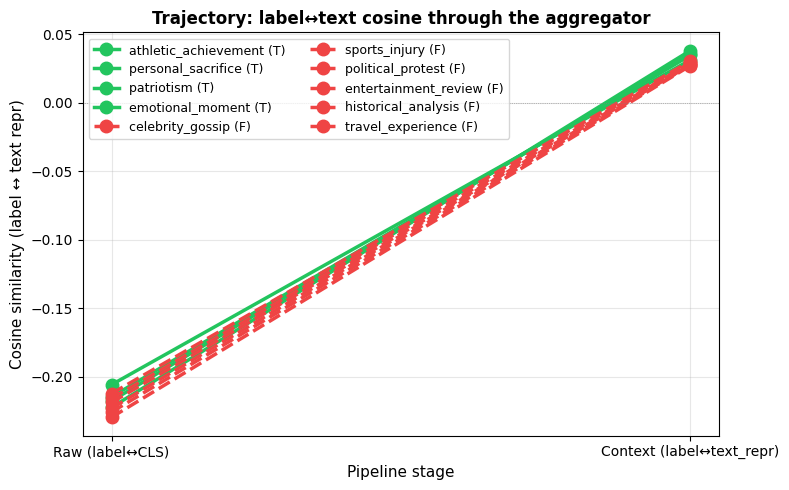


Label                    Raw↔CLS  ↔text_repr        Δ
───────────────────────────────────────────────────────
athletic_achievement      -0.218       0.036   +0.253
personal_sacrifice        -0.206       0.031   +0.237
patriotism                -0.215       0.035   +0.249
emotional_moment          -0.222       0.038   +0.260
celebrity_gossip          -0.226       0.028   +0.253
sports_injury             -0.212       0.030   +0.243
political_protest         -0.230       0.027   +0.257
entertainment_review      -0.219       0.028   +0.246
historical_analysis       -0.223       0.029   +0.252
travel_experience         -0.216       0.029   +0.245


In [9]:
# Trajectory: label↔text cosine at each stage
stage_names = ["Raw (label↔CLS)", "Context (label↔text_repr)"]

trajectory = np.column_stack([sim_raw, sim_context])

fig, ax = plt.subplots(figsize=(8, 5))

for i, (lbl, exp) in enumerate(zip(labels, expected)):
    color = "#22c55e" if exp else "#ef4444"
    ls = "-" if exp else "--"
    ax.plot(stage_names, trajectory[i], marker="o", color=color, ls=ls,
            lw=2.5, markersize=9, label=f"{lbl} ({'T' if exp else 'F'})")

ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_ylabel("Cosine similarity (label ↔ text repr)", fontsize=11)
ax.set_xlabel("Pipeline stage", fontsize=11)
ax.set_title("Trajectory: label↔text cosine through the aggregator",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Delta table
print(f"\n{'Label':<22} {'Raw↔CLS':>9} {'↔text_repr':>11} {'Δ':>8}")
print("─" * 55)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    delta = trajectory[i, 1] - trajectory[i, 0]
    print(f"{lbl:<22} {trajectory[i,0]:>9.3f} {trajectory[i,1]:>11.3f} {delta:>+8.3f}")